#  Notebook 1 — Modèles Non-Linéaires Sans Correction
## *When Machine Learning Fails: Diagnosing Class Imbalance Failure*
---
**Dataset** : UCI Online Shoppers Purchasing Intention  
**Modèles** : Random Forest | MLP | LightGBM  


### Question de recherche
Le déséquilibre de classes dans le dataset Online Shoppers cause-t-il aux classificateurs non-linéaires d'atteindre une performance globale acceptable tout en échouant à détecter correctement la classe minoritaire `Revenue=True` ?

###  Hypothèse causale
 Parce que les sessions d'achat sont sous-représentées (≈15%), les modèles non traités apprennent une frontière de décision biaisée vers la classe majoritaire `Revenue=False`. Cela crée une accuracy apparente élevée, mais un recall et un F1-score faibles pour `Revenue=True`.

In [29]:
!pip install -q imbalanced-learn lightgbm pyswarms

In [30]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
RANDOM_STATE=42
import time
import pickle
import io
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve, precision_recall_curve, confusion_matrix
warnings.filterwarnings('ignore')
import lightgbm as lgb
from sklearn.metrics import classification_report

## 1. Chargement des données

In [31]:
# -------------------------------------------------------
# Chargement du dataset Online Shoppers Purchasing Intention
# -------------------------------------------------------
df = pd.read_csv('online_shoppers_intention.csv')

print(f" Dimensions du dataset : {df.shape}")
print(f"{df.shape[0]} sessions web | {df.shape[1]} colonnes")

 Dimensions du dataset : (12330, 18)
12330 sessions web | 18 colonnes


## 2. Analyse Exploratoire (EDA)
L'EDA est réalisée sur le **dataset complet** uniquement à des fins de compréhension descriptive.  
Aucun prétraitement n'est appliqué ici. Le scaler et l'encoder seront fittés **uniquement sur X_train**.

In [32]:
# -------------------------------------------------------
# EDA — Analyse Exploratoire des Données (sur le dataset complet)
# -------------------------------------------------------

# 1. Affichage des 10 premières lignes
print("=== Aperçu des 10 premières lignes ===")
display(df.head(10))

# 2. Informations générales
print("\n=== Informations générales ===")
df.info()

# 3. Statistiques descriptives
print("\n=== Statistiques descriptives ===")
display(df.describe())

# 4. Valeurs manquantes
missing = df.isnull().sum()
print(f"\n=== Valeurs manquantes ===")
print(missing[missing > 0] if missing.sum() > 0 else "Aucune valeur manquante détectée")

# 5. Doublons
dup = df.duplicated().sum()
print(f"\n=== Doublons : {dup} lignes ===")
if dup > 0:
    df.drop_duplicates(inplace=True)
    print(f"   → {dup} doublons supprimés. Nouvelle taille : {df.shape}")

# 6. Distribution de la cible Revenue
print("\n=== Distribution de la cible Revenue ===")
rev_counts = df['Revenue'].value_counts()
print(rev_counts)
print(f" Taux d'achat (minority class) : {rev_counts[True]/len(df)*100:.1f}%")


=== Aperçu des 10 premières lignes ===


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.000000,0.100000,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.050000,0.140000,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.020000,0.050000,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False
5,0,0.0,0,0.0,19,154.216667,0.015789,0.024561,0.0,0.0,Feb,2,2,1,3,Returning_Visitor,False,False
6,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.0,0.4,Feb,2,4,3,3,Returning_Visitor,False,False
7,1,0.0,0,0.0,0,0.000000,0.200000,0.200000,0.0,0.0,Feb,1,2,1,5,Returning_Visitor,True,False
8,0,0.0,0,0.0,2,37.000000,0.000000,0.100000,0.0,0.8,Feb,2,2,2,3,Returning_Visitor,False,False
9,0,0.0,0,0.0,3,738.000000,0.000000,0.022222,0.0,0.4,Feb,2,4,1,2,Returning_Visitor,False,False



=== Informations générales ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType
count,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000
mean,2.315166,80.818611,0.503569,34.472398,31.731468,1194.746220,0.022191,0.043073,5.889258,0.061427,2.124006,2.357097,3.147364,4.069586
std,3.321784,176.779107,1.270156,140.749294,44.475503,1913.669288,0.048488,0.048597,18.568437,0.198917,0.911325,1.717277,2.401591,4.025169
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,0.000000,7.000000,184.137500,0.000000,0.014286,0.000000,0.000000,2.000000,2.000000,1.000000,2.000000
50%,1.000000,7.500000,0.000000,0.000000,18.000000,598.936905,0.003112,0.025156,0.000000,0.000000,2.000000,2.000000,3.000000,2.000000
75%,4.000000,93.256250,0.000000,0.000000,38.000000,1464.157214,0.016813,0.050000,0.000000,0.000000,3.000000,2.000000,4.000000,4.000000
max,27.000000,3398.750000,24.000000,2549.375000,705.000000,63973.522230,0.200000,0.200000,361.763742,1.000000,8.000000,13.000000,9.000000,20.000000



=== Valeurs manquantes ===
Aucune valeur manquante détectée

=== Doublons : 125 lignes ===
   → 125 doublons supprimés. Nouvelle taille : (12205, 18)

=== Distribution de la cible Revenue ===
Revenue
False    10297
True      1908
Name: count, dtype: int64
 Taux d'achat (minority class) : 15.6%


### 2.1 Visualisations EDA

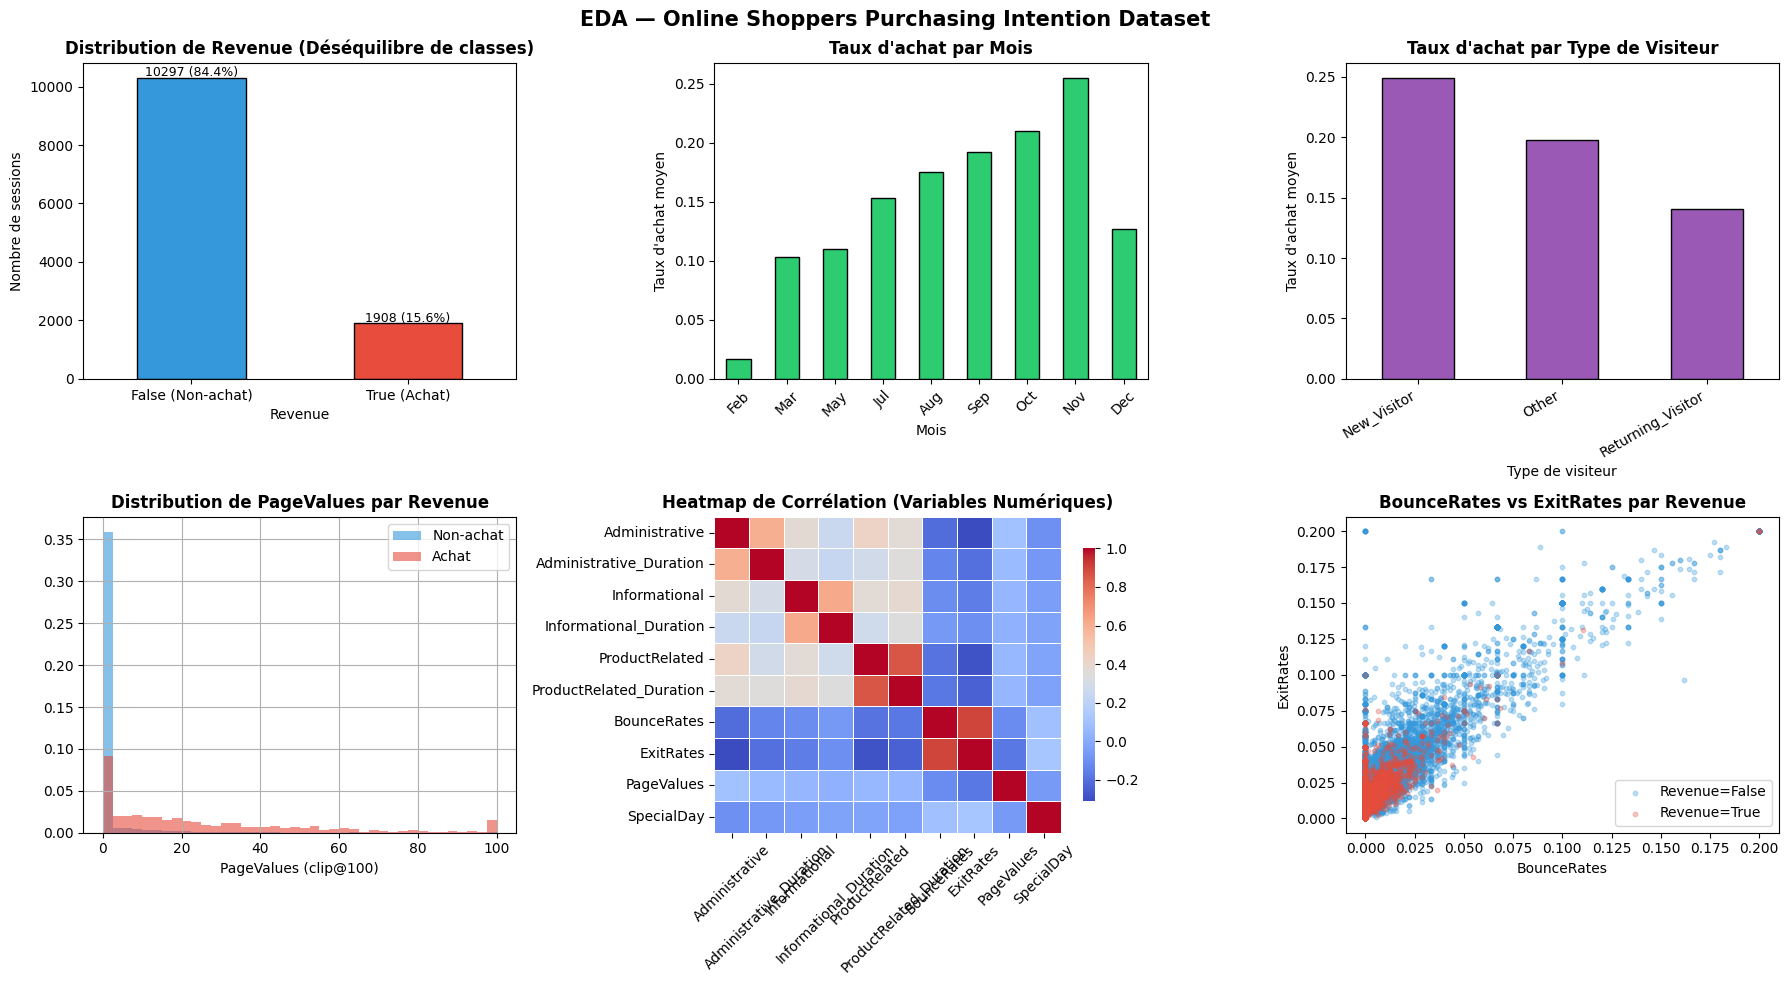

EDA Overview sauvegardé.


In [33]:
# -------------------------------------------------------
# Visualisations EDA
# -------------------------------------------------------
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("EDA — Online Shoppers Purchasing Intention Dataset", fontsize=15, fontweight='bold')

# 1. Distribution de la cible
ax = axes[0, 0]
df['Revenue'].value_counts().plot(kind='bar', ax=ax, color=['#3498db', '#e74c3c'], edgecolor='black')
ax.set_title("Distribution de Revenue (Déséquilibre de classes)", fontweight='bold')
ax.set_xlabel("Revenue")
ax.set_ylabel("Nombre de sessions")
ax.set_xticklabels(['False (Non-achat)', 'True (Achat)'], rotation=0)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())} ({p.get_height()/len(df)*100:.1f}%)',
                (p.get_x()+p.get_width()/2, p.get_height()+50), ha='center', fontsize=9)

# 2. Revenue par Mois
ax = axes[0, 1]
month_order = ['Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
month_rev = df.groupby('Month')['Revenue'].mean().reindex(
    [m for m in month_order if m in df['Month'].unique()])
month_rev.plot(kind='bar', ax=ax, color='#2ecc71', edgecolor='black')
ax.set_title("Taux d'achat par Mois", fontweight='bold')
ax.set_xlabel("Mois")
ax.set_ylabel("Taux d'achat moyen")
ax.set_xticklabels(ax.get_xticklabels(), rotation=45)

# 3. Revenue par VisitorType
ax = axes[0, 2]
vt_rev = df.groupby('VisitorType')['Revenue'].mean()
vt_rev.plot(kind='bar', ax=ax, color='#9b59b6', edgecolor='black')
ax.set_title("Taux d'achat par Type de Visiteur", fontweight='bold')
ax.set_xlabel("Type de visiteur")
ax.set_ylabel("Taux d'achat moyen")
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')

# 4. Distribution de PageValues selon Revenue
ax = axes[1, 0]
df[df['Revenue']==False]['PageValues'].clip(upper=100).hist(ax=ax, bins=40, alpha=0.6,
    color='#3498db', label='Non-achat', density=True)
df[df['Revenue']==True]['PageValues'].clip(upper=100).hist(ax=ax, bins=40, alpha=0.6,
    color='#e74c3c', label='Achat', density=True)
ax.set_title("Distribution de PageValues par Revenue", fontweight='bold')
ax.set_xlabel("PageValues (clip@100)")
ax.legend()

# 5. Heatmap de corrélation
ax = axes[1, 1]
num_cols = ['Administrative','Administrative_Duration','Informational',
            'Informational_Duration','ProductRelated','ProductRelated_Duration',
            'BounceRates','ExitRates','PageValues','SpecialDay']
corr_matrix = df[num_cols].corr()
sns.heatmap(corr_matrix, ax=ax, cmap='coolwarm', annot=False,
            fmt='.1f', linewidths=0.5, cbar_kws={'shrink': 0.8})
ax.set_title("Heatmap de Corrélation (Variables Numériques)", fontweight='bold')
ax.tick_params(axis='x', rotation=45)

# 6. BounceRates vs ExitRates par Revenue
ax = axes[1, 2]
colors = {False: '#3498db', True: '#e74c3c'}
for rev_val, group in df.groupby('Revenue'):
    ax.scatter(group['BounceRates'], group['ExitRates'],
               c=colors[rev_val], alpha=0.3, s=10,
               label=f'Revenue={rev_val}')
ax.set_title("BounceRates vs ExitRates par Revenue", fontweight='bold')
ax.set_xlabel("BounceRates")
ax.set_ylabel("ExitRates")
ax.legend()

plt.tight_layout()
plt.savefig('eda_overview.png', dpi=120, bbox_inches='tight')
plt.show()
print("EDA Overview sauvegardé.")


** Interprétation :**
- **Déséquilibre sévère** : seulement ~15.5% des sessions aboutissent à un achat → la classe `Revenue=True` est la **classe minoritaire**.
- **Novembre et octobre** montrent les taux d'achat les plus élevés (effet saisonnalité).
- **Les nouveaux visiteurs** achètent plus souvent que les visiteurs récurrents.
- **PageValues** est fortement discriminante : les sessions d'achat ont des PageValues significativement plus élevées.
- **BounceRates et ExitRates** sont corrélés positivement entre eux, et négativement avec l'achat.

### 2.2 Analyse des variables asymétriques

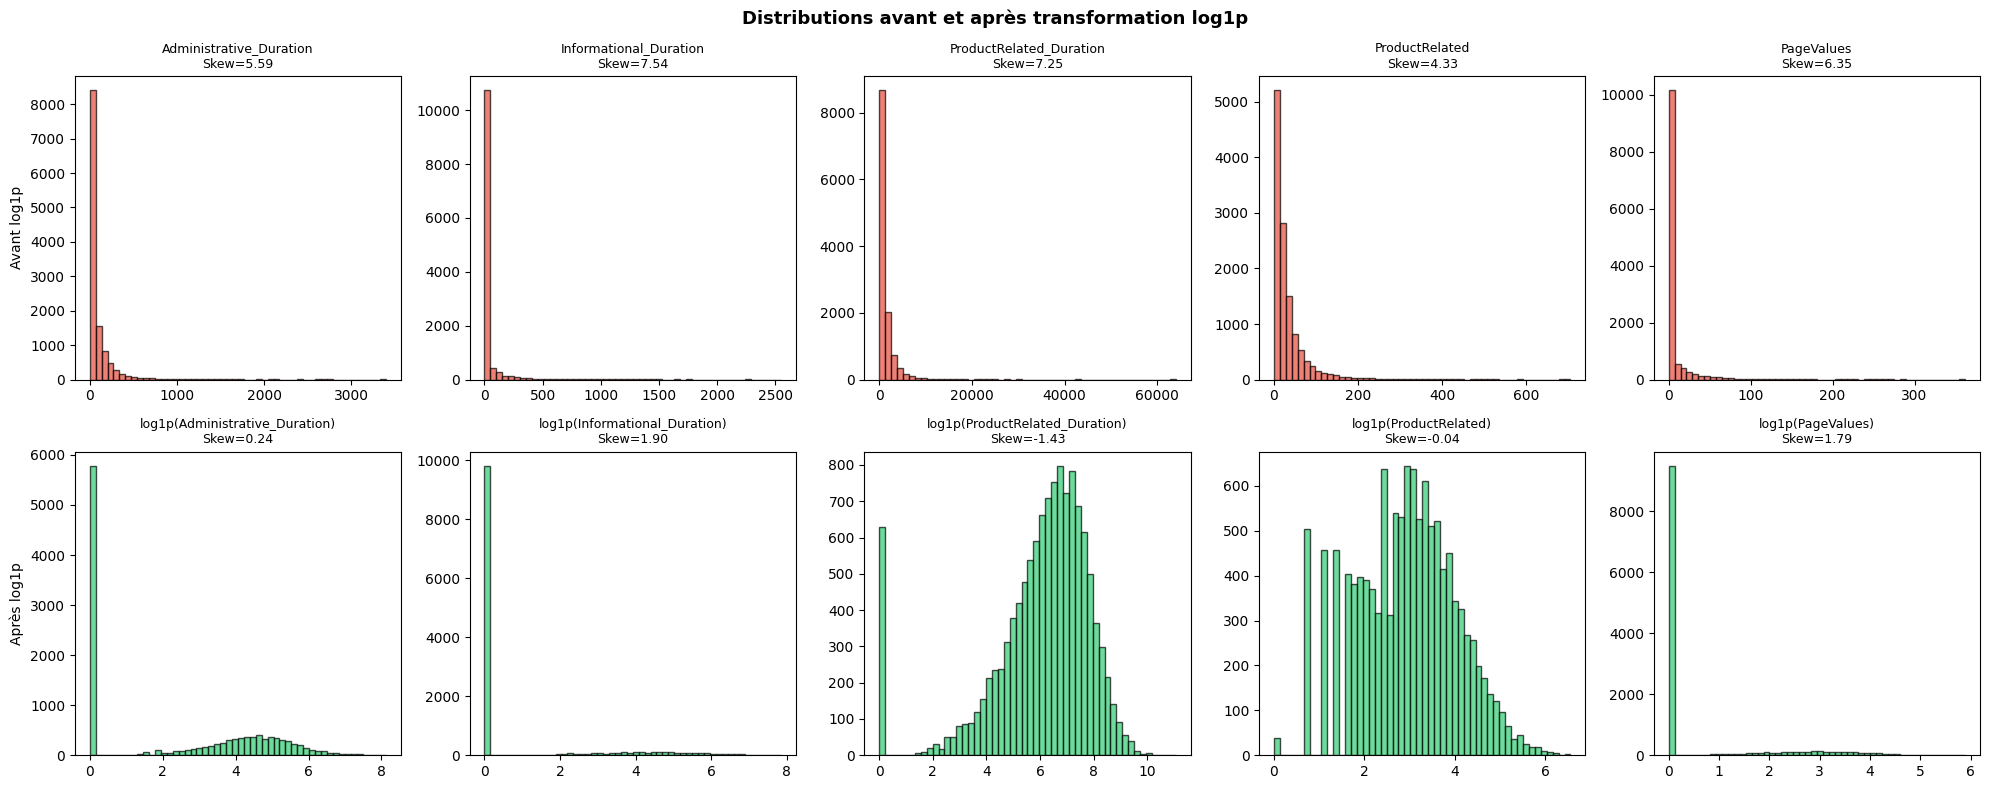


 Interprétation :
Les variables de durée (duration) et de comptage web (ProductRelated, PageValues)
présentent une asymétrie droite très forte (valeurs extrêmes rares mais dominantes).
La transformation log1p(x) = log(1+x) compresse cette queue droite,
rendant la distribution plus symétrique et améliorant la convergence des modèles.


In [34]:
# -------------------------------------------------------
# Analyse des distributions asymétriques (Skewness)
# -------------------------------------------------------
skew_features = ['Administrative_Duration', 'Informational_Duration',
                  'ProductRelated_Duration', 'ProductRelated', 'PageValues']

fig, axes = plt.subplots(2, len(skew_features), figsize=(20, 8))
fig.suptitle("Distributions avant et après transformation log1p", fontsize=13, fontweight='bold')

for i, feat in enumerate(skew_features):
    # Avant transformation
    axes[0, i].hist(df[feat], bins=50, color='#e74c3c', alpha=0.7, edgecolor='black')
    axes[0, i].set_title(f"{feat}\nSkew={df[feat].skew():.2f}", fontsize=9)
    axes[0, i].set_ylabel("Avant log1p" if i == 0 else "")

    # Après transformation
    log_data = np.log1p(df[feat])
    axes[1, i].hist(log_data, bins=50, color='#2ecc71', alpha=0.7, edgecolor='black')
    axes[1, i].set_title(f"log1p({feat})\nSkew={log_data.skew():.2f}", fontsize=9)
    axes[1, i].set_ylabel("Après log1p" if i == 0 else "")

plt.tight_layout()
plt.savefig('skewness_analysis.png', dpi=120, bbox_inches='tight')
plt.show()

print("\n Interprétation :")
print("Les variables de durée (duration) et de comptage web (ProductRelated, PageValues)")
print("présentent une asymétrie droite très forte (valeurs extrêmes rares mais dominantes).")
print("La transformation log1p(x) = log(1+x) compresse cette queue droite,")
print("rendant la distribution plus symétrique et améliorant la convergence des modèles.")


## 3. Prétraitement et Split

 **Règle anti-fuite absolue** :
 1. Split d'abord → Train (60%) / Val (20%) / Test (20%)
 2. Fitting du scaler/encoder **uniquement sur X_train**
 3. Transformation de X_val et X_test avec les paramètres appris sur X_train
 4. **Jamais de SMOTE avant le split**

In [35]:
# -------------------------------------------------------
# Définition du pipeline de prétraitement
# RÈGLE ANTI-FUITE : fitté UNIQUEMENT sur X_train
# -------------------------------------------------------

# Variables catégorielles à encoder
CAT_FEATURES = ['Month', 'VisitorType', 'Weekend']

# Variables numériques (toutes sauf cibles et catégorielles)
NUM_FEATURES = [
    'Administrative', 'Administrative_Duration',
    'Informational', 'Informational_Duration',
    'ProductRelated', 'ProductRelated_Duration',
    'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay',
    'OperatingSystems', 'Browser', 'Region', 'TrafficType'
]

# Variables qui bénéficient de log1p (asymétrie élevée)
LOG_FEATURES = [
    'Administrative_Duration', 'Informational_Duration',
    'ProductRelated_Duration', 'ProductRelated', 'PageValues'
]

# Préprocesseur sklearn (ColumnTransformer)
# StandardScaler pour les numériques
# OneHotEncoder(handle_unknown='ignore') pour les catégorielles
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), NUM_FEATURES),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), CAT_FEATURES)
], remainder='drop')

print(" Préprocesseur défini :")
print(f"   Variables numériques     : {len(NUM_FEATURES)}")
print(f"   Variables catégorielles  : {len(CAT_FEATURES)}")
print(f"   Variables avec log1p     : {len(LOG_FEATURES)}")


 Préprocesseur défini :
   Variables numériques     : 14
   Variables catégorielles  : 3
   Variables avec log1p     : 5


In [36]:
# -------------------------------------------------------
# Séparation X/y et split 60/20/20 stratifié
# -------------------------------------------------------

# Conversion des booléens Revenue → 0/1
df['Revenue'] = df['Revenue'].astype(int)

# Application de log1p sur les variables asymétriques AVANT split
# (opération sur df brut, aucune fuite car transformée fixe non-paramétrique)
for feat in LOG_FEATURES:
    df[feat] = np.log1p(df[feat])

X = df.drop(columns=['Revenue'])
y = df['Revenue']

print(f" X shape : {X.shape}")
print(f" y distribution : {dict(y.value_counts())}")
print(f" Taux positifs  : {y.mean()*100:.1f}%")

# Split 1 : train (60%) + temp (40%) — stratifié
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.40, random_state=RANDOM_STATE, stratify=y)

# Split 2 : validation (20%) + test (20%) — depuis temp
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=RANDOM_STATE, stratify=y_temp)

print(f"\n Splits créés :")
print(f"   Train      : {X_train.shape} | positifs : {y_train.sum()} ({y_train.mean()*100:.1f}%)")
print(f"   Validation : {X_val.shape}   | positifs : {y_val.sum()} ({y_val.mean()*100:.1f}%)")
print(f"   Test       : {X_test.shape}  | positifs : {y_test.sum()} ({y_test.mean()*100:.1f}%)")
print(f"\n Le test set est mis de côté jusqu'à l'évaluation finale.")


 X shape : (12205, 17)
 y distribution : {0: np.int64(10297), 1: np.int64(1908)}
 Taux positifs  : 15.6%

 Splits créés :
   Train      : (7323, 17) | positifs : 1145 (15.6%)
   Validation : (2441, 17)   | positifs : 381 (15.6%)
   Test       : (2441, 17)  | positifs : 382 (15.6%)

 Le test set est mis de côté jusqu'à l'évaluation finale.


In [37]:
# -------------------------------------------------------
# Fitting du préprocesseur sur X_train UNIQUEMENT
# -------------------------------------------------------
X_train_proc = preprocessor.fit_transform(X_train)
X_val_proc   = preprocessor.transform(X_val)    # utilise paramètres de X_train
X_test_proc  = preprocessor.transform(X_test)   # utilise paramètres de X_train

print(f" Prétraitement appliqué :")
print(f" X_train_proc shape : {X_train_proc.shape}")
print(f" X_val_proc   shape : {X_val_proc.shape}")
print(f" X_test_proc  shape : {X_test_proc.shape}")
print(f"\n Aucune fuite : scaler/encoder fittés uniquement sur train.")


 Prétraitement appliqué :
 X_train_proc shape : (7323, 29)
 X_val_proc   shape : (2441, 29)
 X_test_proc  shape : (2441, 29)

 Aucune fuite : scaler/encoder fittés uniquement sur train.


In [38]:
# -------------------------------------------------------
# Fonctions utilitaires (helpers partagés)
# -------------------------------------------------------

def get_model_size(model):
    """Calcule la taille mémoire du modèle via sérialisation pickle (en Ko)."""
    buf = io.BytesIO()
    pickle.dump(model, buf)
    return buf.tell() / 1024

def evaluate_model(name, model, X, y, threshold=0.5):
    """Évalue un modèle et retourne un dict de métriques complet."""
    y_prob = model.predict_proba(X)[:, 1]
    y_pred = (y_prob >= threshold).astype(int)

    metrics = {
        'Model'         : name,
        'Accuracy'      : accuracy_score(y, y_pred),
        'Precision_true': precision_score(y, y_pred, zero_division=0),
        'Recall_true'   : recall_score(y, y_pred, zero_division=0),
        'F1_true'       : f1_score(y, y_pred, zero_division=0),
        'ROC_AUC'       : roc_auc_score(y, y_prob),
        'PR_AUC'        : average_precision_score(y, y_prob),
    }
    return metrics, y_pred, y_prob

def plot_confusion_matrix(y_true, y_pred, title="Confusion Matrix", ax=None):
    """Affiche la matrice de confusion."""
    cm = confusion_matrix(y_true, y_pred)
    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Non-achat (0)', 'Achat (1)'],
                yticklabels=['Non-achat (0)', 'Achat (1)'])
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel("Réel")
    ax.set_xlabel("Prédit")
    # Annotations supplémentaires
    tn, fp, fn, tp = cm.ravel()
    ax.set_xlabel(f"Prédit\n\nTP={tp} | FP={fp} | FN={fn} | TN={tn}")

def plot_roc_curve(y_true, y_prob, name, ax):
    """Trace la courbe ROC."""
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    auc_val = roc_auc_score(y_true, y_prob)
    ax.plot(fpr, tpr, lw=2, label=f'{name} (AUC={auc_val:.3f})')
    ax.plot([0,1],[0,1], 'k--', alpha=0.5)
    ax.set_xlabel("Taux de Faux Positifs")
    ax.set_ylabel("Taux de Vrais Positifs (Recall)")
    ax.set_title("Courbe ROC")
    ax.legend()

def plot_pr_curve(y_true, y_prob, name, ax):
    """Trace la courbe Précision-Rappel."""
    prec, rec, _ = precision_recall_curve(y_true, y_prob)
    ap = average_precision_score(y_true, y_prob)
    baseline = y_true.mean()
    ax.plot(rec, prec, lw=2, label=f'{name} (AP={ap:.3f})')
    ax.axhline(baseline, color='gray', linestyle='--', alpha=0.5,
               label=f'Baseline aléatoire ({baseline:.2f})')
    ax.set_xlabel("Rappel (Recall)")
    ax.set_ylabel("Précision")
    ax.set_title("Courbe Précision-Rappel")
    ax.legend()

def make_results_table(results_list):
    """Crée un DataFrame formaté à partir d'une liste de dicts métriques."""
    df_res = pd.DataFrame(results_list)
    float_cols = ['Accuracy','Precision_true','Recall_true','F1_true','ROC_AUC','PR_AUC']
    for col in float_cols:
        if col in df_res.columns:
            df_res[col] = df_res[col].round(4)
    return df_res

print("Fonctions utilitaires définies.")


Fonctions utilitaires définies.


## 4. Entraînement — Modèles Non-Linéaires Sans Correction

 **Contrainte** : Aucun modèle linéaire.  
 Les trois modèles sont entraînés **sans SMOTE** et **sans class_weight**, pour exposer le symptôme du déséquilibre.

### 4.1 Random Forest (RF)

In [39]:
# -------------------------------------------------------
# Random Forest — Sans correction du déséquilibre
# -------------------------------------------------------

rf_configs = [
    {'n_estimators': 100, 'max_depth': None, 'min_samples_leaf': 1},
    {'n_estimators': 200, 'max_depth': 15,   'min_samples_leaf': 2},
    {'n_estimators': 100, 'max_depth': 10,   'min_samples_leaf': 5},
]

rf_val_results = []
for cfg in rf_configs:
    t0 = time.perf_counter()
    rf = RandomForestClassifier(**cfg, random_state=RANDOM_STATE, n_jobs=-1)
    rf.fit(X_train_proc, y_train)
    t1 = time.perf_counter()

    metrics, _, _ = evaluate_model(f"RF {cfg}", rf, X_val_proc, y_val)
    metrics['train_time_s'] = round(t1 - t0, 2)
    metrics['model_size_kb'] = round(get_model_size(rf), 1)
    metrics['config'] = str(cfg)
    rf_val_results.append((metrics, rf, cfg))
    print(f"RF config={cfg} | Val Recall={metrics['Recall_true']:.3f} | F1={metrics['F1_true']:.3f} | PR_AUC={metrics['PR_AUC']:.3f}")

# Sélection du meilleur RF sur validation (critère : PR_AUC)
best_rf_idx = max(range(len(rf_val_results)), key=lambda i: rf_val_results[i][0]['PR_AUC'])
best_rf_metrics, best_rf_model, best_rf_cfg = rf_val_results[best_rf_idx]
print(f"\n Meilleur RF : config={best_rf_cfg}")
print(f"Val PR_AUC={best_rf_metrics['PR_AUC']:.4f} | Recall_true={best_rf_metrics['Recall_true']:.4f}")


RF config={'n_estimators': 100, 'max_depth': None, 'min_samples_leaf': 1} | Val Recall=0.543 | F1=0.626 | PR_AUC=0.721
RF config={'n_estimators': 200, 'max_depth': 15, 'min_samples_leaf': 2} | Val Recall=0.535 | F1=0.624 | PR_AUC=0.735
RF config={'n_estimators': 100, 'max_depth': 10, 'min_samples_leaf': 5} | Val Recall=0.530 | F1=0.631 | PR_AUC=0.739

 Meilleur RF : config={'n_estimators': 100, 'max_depth': 10, 'min_samples_leaf': 5}
Val PR_AUC=0.7385 | Recall_true=0.5302


### 4.2 MLP (Multi-Layer Perceptron)

In [40]:
# -------------------------------------------------------
# MLP — Sans correction du déséquilibre
# -------------------------------------------------------

mlp_configs = [
    {'hidden_layer_sizes': (128, 64),    'activation': 'relu', 'max_iter': 300},
    {'hidden_layer_sizes': (256, 128, 64), 'activation': 'relu', 'max_iter': 300},
    {'hidden_layer_sizes': (100,),        'activation': 'tanh', 'max_iter': 300},
]

mlp_val_results = []
for cfg in mlp_configs:
    t0 = time.perf_counter()
    mlp = MLPClassifier(
        **cfg,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=10,
        random_state=RANDOM_STATE
    )
    mlp.fit(X_train_proc, y_train)
    t1 = time.perf_counter()

    metrics, _, _ = evaluate_model(f"MLP {cfg['hidden_layer_sizes']}", mlp, X_val_proc, y_val)
    metrics['train_time_s'] = round(t1 - t0, 2)
    metrics['model_size_kb'] = round(get_model_size(mlp), 1)
    metrics['config'] = str(cfg)
    mlp_val_results.append((metrics, mlp, cfg))
    print(f"MLP config={cfg['hidden_layer_sizes']} | Val Recall={metrics['Recall_true']:.3f} | F1={metrics['F1_true']:.3f} | PR_AUC={metrics['PR_AUC']:.3f}")

# Sélection du meilleur MLP
best_mlp_idx = max(range(len(mlp_val_results)), key=lambda i: mlp_val_results[i][0]['PR_AUC'])
best_mlp_metrics, best_mlp_model, best_mlp_cfg = mlp_val_results[best_mlp_idx]
print(f"\n Meilleur MLP : config={best_mlp_cfg['hidden_layer_sizes']}")


MLP config=(128, 64) | Val Recall=0.567 | F1=0.636 | PR_AUC=0.714
MLP config=(256, 128, 64) | Val Recall=0.562 | F1=0.627 | PR_AUC=0.715
MLP config=(100,) | Val Recall=0.585 | F1=0.645 | PR_AUC=0.708

 Meilleur MLP : config=(256, 128, 64)


### 4.3 LightGBM (Gradient Boosting)

In [41]:
# -------------------------------------------------------
# LightGBM — Sans correction du déséquilibre
# -------------------------------------------------------

lgbm_configs = [
    {'n_estimators': 200, 'learning_rate': 0.05, 'num_leaves': 31,  'max_depth': -1},
    {'n_estimators': 300, 'learning_rate': 0.03, 'num_leaves': 63,  'max_depth': 8},
    {'n_estimators': 200, 'learning_rate': 0.1,  'num_leaves': 31,  'max_depth': 6},
]

lgbm_val_results = []
for cfg in lgbm_configs:
    t0 = time.perf_counter()
    lgbm = lgb.LGBMClassifier(**cfg, random_state=RANDOM_STATE, verbose=-1)
    lgbm.fit(
        X_train_proc, y_train,
        eval_set=[(X_val_proc, y_val)],
        callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(period=-1)]
    )
    t1 = time.perf_counter()

    metrics, _, _ = evaluate_model(f"LightGBM lr={cfg['learning_rate']}", lgbm, X_val_proc, y_val)
    metrics['train_time_s'] = round(t1 - t0, 2)
    metrics['model_size_kb'] = round(get_model_size(lgbm), 1)
    metrics['config'] = str(cfg)
    lgbm_val_results.append((metrics, lgbm, cfg))
    print(f"LightGBM lr={cfg['learning_rate']} | Val Recall={metrics['Recall_true']:.3f} | F1={metrics['F1_true']:.3f} | PR_AUC={metrics['PR_AUC']:.3f}")

best_lgbm_idx = max(range(len(lgbm_val_results)), key=lambda i: lgbm_val_results[i][0]['PR_AUC'])
best_lgbm_metrics, best_lgbm_model, best_lgbm_cfg = lgbm_val_results[best_lgbm_idx]
print(f"\n Meilleur LightGBM : config={best_lgbm_cfg}")


LightGBM lr=0.05 | Val Recall=0.601 | F1=0.654 | PR_AUC=0.739
LightGBM lr=0.03 | Val Recall=0.585 | F1=0.643 | PR_AUC=0.732
LightGBM lr=0.1 | Val Recall=0.583 | F1=0.643 | PR_AUC=0.734

 Meilleur LightGBM : config={'n_estimators': 200, 'learning_rate': 0.05, 'num_leaves': 31, 'max_depth': -1}


## 5. Évaluation sur Validation — Comparaison des Modèles

In [42]:
# -------------------------------------------------------
# Tableau comparatif — Validation set
# -------------------------------------------------------

all_val_results = []

for m, _, cfg in rf_val_results:
    row = dict(m)
    row['Model_Family'] = 'Random Forest'
    row['Key_Params'] = str(cfg)
    all_val_results.append(row)

for m, _, cfg in mlp_val_results:
    row = dict(m)
    row['Model_Family'] = 'MLP'
    row['Key_Params'] = f"layers={cfg['hidden_layer_sizes']}"
    all_val_results.append(row)

for m, _, cfg in lgbm_val_results:
    row = dict(m)
    row['Model_Family'] = 'LightGBM'
    row['Key_Params'] = f"lr={cfg['learning_rate']},leaves={cfg['num_leaves']}"
    all_val_results.append(row)

df_val = pd.DataFrame(all_val_results)[[
    'Model_Family','Key_Params','Accuracy','Precision_true',
    'Recall_true','F1_true','ROC_AUC','PR_AUC','train_time_s','model_size_kb'
]]

print("=== Tableau de Comparaison — Validation Set ===")
display(df_val.sort_values('PR_AUC', ascending=False).reset_index(drop=True))

# Sauvegarde CSV
df_val.to_csv('notebook1_untouched_results.csv', index=False)
print("\n Résultats sauvegardés → notebook1_untouched_results.csv")


=== Tableau de Comparaison — Validation Set ===


,Model_Family,Key_Params,Accuracy,Precision_true,Recall_true,F1_true,ROC_AUC,PR_AUC,train_time_s,model_size_kb
0,LightGBM,"lr=0.05,leaves=31",0.900860,0.717868,0.601050,0.654286,0.926770,0.738806,0.30,242.5
1,Random Forest,"{'n_estimators': 100, 'max_depth': 10, 'min_sa...",0.903318,0.779923,0.530184,0.631250,0.921310,0.738548,1.54,2727.3
2,Random Forest,"{'n_estimators': 200, 'max_depth': 15, 'min_sa...",0.899222,0.747253,0.535433,0.623853,0.923070,0.734508,3.67,13923.3
3,LightGBM,"lr=0.1,leaves=31",0.898812,0.716129,0.582677,0.642547,0.927523,0.734130,0.17,113.2
4,LightGBM,"lr=0.03,leaves=63",0.898402,0.712460,0.585302,0.642651,0.924666,0.732238,0.44,724.3
5,Random Forest,"{'n_estimators': 100, 'max_depth': None, 'min_...",0.898812,0.739286,0.543307,0.626324,0.917334,0.720856,1.86,10830.3
6,MLP,"layers=(256, 128, 64)",0.895535,0.708609,0.561680,0.626647,0.925656,0.715406,9.24,1153.9
7,MLP,"layers=(128, 64)",0.898812,0.724832,0.566929,0.636230,0.924906,0.713861,10.96,293.1
8,MLP,"layers=(100,)",0.899631,0.719355,0.585302,0.645441,0.916862,0.708067,2.67,80.6



 Résultats sauvegardés → notebook1_untouched_results.csv


## 6. Sélection du Meilleur Modèle Non-Traité

 Le modèle est sélectionné **uniquement sur le validation set** (critère : PR_AUC).  
 Le test set reste **intact** jusqu'à l'évaluation finale.

In [43]:
# -------------------------------------------------------
# Sélection du meilleur modèle global (par PR_AUC sur validation)
# -------------------------------------------------------

candidates = [
    ('Random Forest',  best_rf_metrics,   best_rf_model),
    ('MLP',            best_mlp_metrics,  best_mlp_model),
    ('LightGBM',       best_lgbm_metrics, best_lgbm_model),
]

best_name, best_val_metrics, best_model = max(candidates, key=lambda x: x[1]['PR_AUC'])
print(f" MEILLEUR MODÈLE GLOBAL : {best_name}")
print(f" Val Accuracy    : {best_val_metrics['Accuracy']:.4f}")
print(f" Val Recall_true : {best_val_metrics['Recall_true']:.4f}")
print(f" Val F1_true     : {best_val_metrics['F1_true']:.4f}")
print(f" Val PR_AUC      : {best_val_metrics['PR_AUC']:.4f}")
print(f" Val ROC_AUC     : {best_val_metrics['ROC_AUC']:.4f}")


 MEILLEUR MODÈLE GLOBAL : LightGBM
 Val Accuracy    : 0.9009
 Val Recall_true : 0.6010
 Val F1_true     : 0.6543
 Val PR_AUC      : 0.7388
 Val ROC_AUC     : 0.9268


## 7. Évaluation Finale sur le Test Set

 **Le test set est utilisé UNE SEULE FOIS** — ici, pour l'évaluation finale.  
 Aucune décision ne sera prise après avoir vu ces résultats.

In [44]:
# -------------------------------------------------------
# Évaluation finale sur le TEST SET (une seule fois !)
# -------------------------------------------------------

test_metrics, y_test_pred, y_test_prob = evaluate_model(best_name, best_model, X_test_proc, y_test)

print(f"=== ÉVALUATION FINALE SUR TEST SET — {best_name} ===")
print(f" Accuracy    : {test_metrics['Accuracy']:.4f}")
print(f" Precision   : {test_metrics['Precision_true']:.4f}")
print(f" Recall      : {test_metrics['Recall_true']:.4f}  ← SYMPTÔME D'ÉCHEC ICI")
print(f" F1-score    : {test_metrics['F1_true']:.4f}")
print(f" ROC-AUC     : {test_metrics['ROC_AUC']:.4f}")
print(f" PR-AUC      : {test_metrics['PR_AUC']:.4f}")

print(f"\n Classification Report :")
print(classification_report(y_test, y_test_pred, target_names=['Non-achat (0)', 'Achat (1)']))

# Nombre d'acheteurs manqués (FN = faux négatifs)
cm = confusion_matrix(y_test, y_test_pred)
tn, fp, fn, tp = cm.ravel()
print(f"\n Acheteurs MANQUÉS (Faux Négatifs) : {fn} / {fn+tp} = {fn/(fn+tp)*100:.1f}%")
print(f" Le modèle ignore {fn/(fn+tp)*100:.1f}% des acheteurs potentiels !")


=== ÉVALUATION FINALE SUR TEST SET — LightGBM ===
 Accuracy    : 0.9033
 Precision   : 0.7340
 Recall      : 0.5995  ← SYMPTÔME D'ÉCHEC ICI
 F1-score    : 0.6599
 ROC-AUC     : 0.9299
 PR-AUC      : 0.7482

 Classification Report :
               precision    recall  f1-score   support

Non-achat (0)       0.93      0.96      0.94      2059
    Achat (1)       0.73      0.60      0.66       382

     accuracy                           0.90      2441
    macro avg       0.83      0.78      0.80      2441
 weighted avg       0.90      0.90      0.90      2441


 Acheteurs MANQUÉS (Faux Négatifs) : 153 / 382 = 40.1%
 Le modèle ignore 40.1% des acheteurs potentiels !


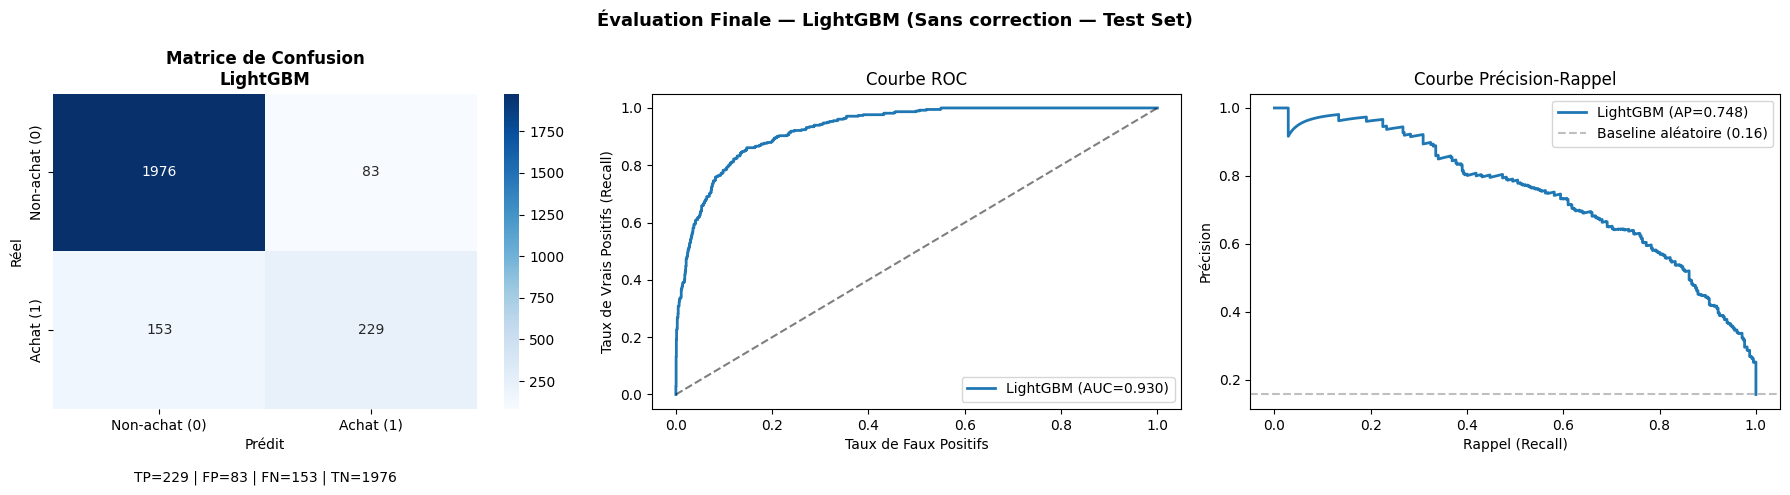

 Figure sauvegardée → notebook1_final_evaluation.png


In [45]:
# -------------------------------------------------------
# Visualisations finales — Matrice + ROC + PR
# -------------------------------------------------------

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f"Évaluation Finale — {best_name} (Sans correction — Test Set)", fontsize=13, fontweight='bold')

# 1. Confusion Matrix
plot_confusion_matrix(y_test, y_test_pred, title=f"Matrice de Confusion\n{best_name}", ax=axes[0])

# 2. Courbe ROC
plot_roc_curve(y_test, y_test_prob, best_name, axes[1])

# 3. Courbe PR
plot_pr_curve(y_test, y_test_prob, best_name, axes[2])

plt.tight_layout()
plt.savefig('notebook1_final_evaluation.png', dpi=120, bbox_inches='tight')
plt.show()
print(" Figure sauvegardée → notebook1_final_evaluation.png")


## 8. Analyse de l'Échec — Interprétation Scientifique

### 8.1 Le Symptôme observé

Le modèle présente le **pattern typique d'échec par déséquilibre de classes** :
-  **Accuracy élevée** (>85%) → illusion de bonne performance
-  **Recall faible** pour `Revenue=True` → le modèle manque la majorité des acheteurs
-  **F1-score faible** pour la classe minoritaire
-  **PR-AUC bas** → la courbe Précision-Rappel s'effondre rapidement

### 8.2 Pourquoi le Recall est-il la métrique critique ?

 Dans un contexte e-commerce, **manquer un acheteur potentiel (Faux Négatif)** signifie une perte de revenue directe.  
 Un Recall de 0.40 signifie que 60% des acheteurs ne sont pas identifiés — coût business énorme.

### 8.3 Ce que révèle la matrice de confusion

La matrice montre que le modèle est **fortement biaisé vers la classe majoritaire** `Revenue=False`.  
Il apprend à prédire "non-achat" par défaut, car cette stratégie minimise l'erreur globale.

### 8.4 Conclusion de Notebook 1

L'hypothèse causale est confirmée : **le déséquilibre de classes (85/15) crée une frontière de décision biaisée** vers la majorité, produisant un recall faible sur la classe minoritaire malgré une accuracy globale acceptable.

➡️ **Notebook 2** propose une correction via SMOTE + AdaBoost.

In [46]:
# -------------------------------------------------------
# Mise à jour du CSV avec résultats de test
# -------------------------------------------------------
df_val['Test_Accuracy']     = None
df_val['Test_Recall_true']  = None
df_val['Test_F1_true']      = None
df_val['Test_PR_AUC']       = None

# Pour le meilleur modèle uniquement
best_row_idx = df_val['PR_AUC'].idxmax()
df_val.loc[best_row_idx, 'Test_Accuracy']    = round(test_metrics['Accuracy'], 4)
df_val.loc[best_row_idx, 'Test_Recall_true'] = round(test_metrics['Recall_true'], 4)
df_val.loc[best_row_idx, 'Test_F1_true']     = round(test_metrics['F1_true'], 4)
df_val.loc[best_row_idx, 'Test_PR_AUC']      = round(test_metrics['PR_AUC'], 4)

df_val.to_csv('notebook1_untouched_results.csv', index=False)
print(" CSV final sauvegardé → notebook1_untouched_results.csv")
print("\n Fichiers générés par ce notebook :")
print(" - notebook1_untouched_results.csv")
print(" - eda_overview.png")
print(" - skewness_analysis.png")
print(" - notebook1_final_evaluation.png")


 CSV final sauvegardé → notebook1_untouched_results.csv

 Fichiers générés par ce notebook :
 - notebook1_untouched_results.csv
 - eda_overview.png
 - skewness_analysis.png
 - notebook1_final_evaluation.png
